# **Task 4: The Turing Test**

---

I have structured Task 4 into two main parts:

**Part 1 — Genetic Algorithm:** The aim will be to evolve AI-generated text through guided mutations to maximise the Tier C DistilBERT classifier's P(Human) score. Each generation will keep the fittest survivors and apply one of three targeted mutation strategies that I have drawn from Task 3's feature analysis.

**Part 2 — Personal Essay Test:** I will write and run an essay through the same detector, compare it against an AI-style rewrite of the same essay, and interpret the result in terms of the detector's known training distribution.

**My Hypotheses**

**H1:** The GA will improve P(Human) over generations but will probably not reach 90%, because the adversarial tests in Task 3 showed that single-feature mutations did not flip the classification. Multiple features (past tense, Victorian vocabulary, syntactic complexity) need to come together, and the GA must discover this combination organically through evolution.

**H2:** My essay will be classified as Generic AI or borderline with Human but not fully Human. In the past 3 tasks, I have seen that the model has no reference for how I write. Its 'Human' class was trained on Victorian fiction, so any real modern writing will fall outside the decision boundary.

<br>

PS. My friends often joke that I write everything very precisely and in a conversational tone. So far, all the tasks have only made me more confident that the model will definitely not recognise my writing as Human.

### **PART 1: Genetic Algorithm**

---

### **1) Imports and Setup**

I will Load the Tier C DistilBERT+LoRA model and define the fitness function for the GA. The model will be loaded exactly as in Task 3: the base `distilbert-base-uncased` will be loaded first, then wrapped with the saved LoRA adapter via `PeftModel.from_pretrained`.

The fitness function `get_human_probability(text)` will return `(P_human, pred_class, all_probs)`. The GA will aim to maximise `P_human`, i.e., the softmax probability assigned to class 0 (Human).

**API key management:** Four Gemini API keys will be loaded from `.env` and wrapped in a `KeyRotator` (same as in Task 0). The rotator will automatically switch to the next key on any **429 / quota / rate-limit error** and sleep before retrying.

This is necessary because `gemini-2.5-flash-lite` has a 20 RPD free-tier limit per key. With 4 keys, I have 80 RPD total capacity against almost 50 calls needed for the full GA run. The rotator will ensure a mid-run rate-limit hit does not corrupt a generation.


In [ ]:
# Same script as Task 3, but with the addition of the KeyRotator class and API key management for Gemini calls in the GA loop

import os, json, re, random, time
import numpy as np
import torch
import matplotlib.pyplot as plt
import google.genai as genai
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from peft import PeftModel
from dotenv import load_dotenv

load_dotenv('../.env')
API_KEY = os.getenv('api_key', '')
API_KEYS = [k.strip() for k in API_KEY.split(',') if k.strip()]

MODELS_DIR  = '../models/distilbert_lora_final'
FIGURES_DIR = '../figures/task4'
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

tokenizer = AutoTokenizer.from_pretrained(MODELS_DIR)
base_model = AutoModelForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels=3
)
model = PeftModel.from_pretrained(base_model, MODELS_DIR)
model = model.to(device)
model.eval()
print('Tier C model loaded successfully.')

label_names = {0: 'Human', 1: 'Generic AI', 2: 'Mimic AI'}

# Fitness function for the GA. It will return P(Human) for a given input text.
def get_human_probability(text):
    inputs = tokenizer(
        text, return_tensors='pt',
        truncation=True, max_length=512,
        padding='max_length'
    ).to(device)
    with torch.no_grad():
        logits = model(**inputs).logits 
    probs = torch.softmax(logits, dim=-1).squeeze().cpu().numpy() # Squeeze removes the batch dimension, leaving shape (3,) where 3 is the number of classes
    pred  = int(np.argmax(probs)) 
    return float(probs[0]), pred, probs  # (P_human, pred_class, all_probs)


# API key rotator from Task 0 which will rotate to the next key automatically when a 429 / quota error is detected
class KeyRotator:
    def __init__(self, keys):
        self.keys = keys
        self.idx  = 0

    def current(self):
        return self.keys[self.idx]

    def rotate(self):
        self.idx = (self.idx + 1) % len(self.keys)
        print(f'  → Rotated to API key index {self.idx}')
        time.sleep(5)

    def get_client(self):
        return genai.Client(api_key=self.current())


rotator = KeyRotator(API_KEYS)
print(f'KeyRotator initialised with {len(API_KEYS)} key(s).')

Loaded 4 API key(s)
Using device: cpu


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Tier C model loaded successfully.
KeyRotator initialised with 4 key(s).


---

### **2) Initial Population**

I will generate the initial population by calling Gemini API on the topic **"Crime, guilt, and redemption"** because I identified it as the topic that produced the **highest baseline P(Human) scores** in Generic AI text in Task 3's Near-Miss analysis. 

This topic induced past-tense narrative, which was the single strongest discriminative feature for the Human class in Task 1 (Near-Miss paragraphs on this topic had P(Human) in the range 0.263–0.309).

I will use a neutral prompt so that the GA has room to evolve style through mutations rather than starting from an already-biased distribution. I will **set the temperature to 0.9** so that the model generates more diverse outputs, which is important for the GA's initial exploration.

This will be a single API call that will generate all 10 paragraphs at once. The call will go through the `KeyRotator` class with retry logic, so that a transient error will not abort the entire run before the GA even starts.

I have added a sleep time of 10 seconds before retries to give time for the rate limit to reset. The `max_attempts` is set to the number of keys plus 2 because in case all keys are rate-limited, I want to allow for one full rotation through the keys and then a couple of retries before giving up.


In [ ]:
MODEL_GEMINI    = 'gemini-2.5-flash-lite'  
TOPIC           = 'Crime, guilt, and redemption'
POPULATION_SIZE = 10
GA_GENERATIONS  = 7
TOP_K           = 3  # Survivors per generation. These will get mutated to create the next generation 

# Function to generate the initial population of paragraphs using the Gemini API
def generate_initial_population(topic, n, rotator):
    prompt = (
        f'Write exactly {n} separate prose paragraphs on the topic: "{topic}"\n\n'
        'Requirements:\n'
        '- Each paragraph must be between 150 and 180 words.\n'
        '- Write in neutral, modern English prose. No lists, no headers.\n'
        '- Each paragraph must tell a small narrative or scene.\n'
        '- Separate paragraphs with one blank line.\n'
        '- No preamble or closing remarks. Output only the paragraphs.'
    )
    max_attempts = len(rotator.keys) + 2 # Trying each key at least once, plus a couple of retries
    attempts = 0
    while attempts < max_attempts:
        try:
            client   = rotator.get_client()
            response = client.models.generate_content(
                model=MODEL_GEMINI,
                contents=prompt,
                config={'temperature': 0.9} # Allow more diversity in the initial population
            )
            raw = response.text if response.text else ''
            if not raw:
                print('  Empty response for initial population. Retrying...')
                attempts += 1 # Incrementing is necessary here to ensure attempts < max_attempts eventually becomes false and prevents an infinite loop
                time.sleep(10) # 10 seconds sleep before retrying
                continue
            blocks     = re.split(r'\n\s*\n', raw.strip()) #Splitting on blank lines to separate paragraphs
            paragraphs = [b.strip() for b in blocks if 100 <= len(b.split()) <= 250] # Filtering paragraphs by word count because Gemini may ignore word count instruction in the prompt
            return paragraphs[:n]
        except Exception as e:
            err = str(e)
            if '429' in err or 'quota' in err.lower() or 'rate' in err.lower():
                print(f'  Rate limit on initial population. Rotating key...')
                rotator.rotate()
                time.sleep(30)
                # Not incrementing attempts here because a rate limit error is not a failed attempt
            else:
                print(f'  API error: {err}. Sleeping 15s...')
                time.sleep(15)
                attempts += 1
    print('WARNING: could not generate initial population after max attempts.')
    return []


# Generating and scoring initial population
print('Generating initial population...')
initial_paragraphs = generate_initial_population(TOPIC, POPULATION_SIZE, rotator)
print(f'Generated {len(initial_paragraphs)} paragraphs')

# Scoring each paragraph with the classifier
population = []
for i, para in enumerate(initial_paragraphs):
    p_human, pred, probs = get_human_probability(para)
    population.append({'text': para, 'p_human': p_human, 'generation': 0})
    print(f'  [{i+1}] P(Human)={p_human:.4f} | Predicted: {label_names[pred]}')

population.sort(key=lambda x: x['p_human'], reverse=True)
print(f'\nGeneration 0 — Best  P(Human): {population[0]["p_human"]:.4f}')
print(f'Generation 0 — Mean P(Human): {np.mean([p["p_human"] for p in population]):.4f}')


Generating initial population...


`use_return_dict` is deprecated! Use `return_dict` instead!


Generated 10 paragraphs
  [1] P(Human)=0.3057 | Predicted: Mimic AI
  [2] P(Human)=0.3044 | Predicted: Generic AI
  [3] P(Human)=0.2884 | Predicted: Mimic AI
  [4] P(Human)=0.3142 | Predicted: Generic AI
  [5] P(Human)=0.3062 | Predicted: Mimic AI
  [6] P(Human)=0.3400 | Predicted: Mimic AI
  [7] P(Human)=0.2573 | Predicted: Mimic AI
  [8] P(Human)=0.2988 | Predicted: Generic AI
  [9] P(Human)=0.2665 | Predicted: Generic AI
  [10] P(Human)=0.3129 | Predicted: Mimic AI

Generation 0 — Best  P(Human): 0.3400
Generation 0 — Mean P(Human): 0.2994


In [ ]:
# Saving initial population paragraphs to a JSONL.
# The 'population' list is sorted best-to-worst by P(Human), so rank 1 = best starting point for the GA.

with open('../data/task4/ga_initial_population.jsonl', 'w', encoding='utf-8') as f:
    for i, p in enumerate(population):
        record = {
            'rank':       i + 1,
            'generation': 0,
            'p_human':    round(p['p_human'], 4),
            'text':       p['text']
        }
        f.write(json.dumps(record) + '\n')

print(f"Saved {len(population)} paragraphs to ../data/task4/ga_initial_population.jsonl")
print("\nTop 3 paragraphs by P(Human):")
for p in population[:3]:
    print(f"\n  [rank {population.index(p)+1}] P(Human)={p['p_human']:.4f}")
    print(f"  {p['text'][:200]}...")


Saved 10 paragraphs to ../data/task4/ga_initial_population.jsonl

Top 3 paragraphs by P(Human):

  [rank 1] P(Human)=0.3400
  Father Michael poured the wine, his movements slow and deliberate. He had heard countless confessions, each one a tapestry of human frailty and desperation. Yet, the young man before him, with his dow...

  [rank 2] P(Human)=0.3142
  The prison yard was a canvas of muted grays and browns, a stark landscape that mirrored the internal desolation of its inhabitants. Marcus sat alone, his gaze fixed on the distant, indifferent sky. He...

  [rank 3] P(Human)=0.3129
  The old bookstore, tucked away on a quiet side street, was a sanctuary for many. Among its dusty shelves, a young man named Leo found solace. He had recently confessed to a theft, a moment of impulsiv...


**Analysis of Initial Population:** 

The mean P(Human) of 0.2994 is near the random baseline (0.333 for a three class classifier) and the best P(Human) of 0.3400 is barely above it. 

The interesting thing is that **six out of ten** paragraphs were classified as Mimic AI. The "crime, guilt, and redemption" probably pushed Gemini into dark and emotional proses. The model must have confused this with attempted Victorian mimicry. 

---

### **3) Genetic Algorithm Loop**

The GA runs for up to 7 generations with the following design:

- **Selection:** GA will keep the top 3 survivors by P(Human) each generation.
- **Mutation:** GA will apply one of three targeted mutation strategies to produce 7 children (population stays at 10). Mutation strategy is sampled uniformly at random per child.
- **Early stopping:** The algo will exit if any individual reaches P(Human) ≥ 0.90.

The three mutation strategies are in-line with Task 3's feature analysis:

1. **Mutation A (Tense register):** The target is to convert all verbs to past tense and add a first-person narrative. This will target the strongest feature from Task 1, `past_tense_ratio`. Even Task 3 confirmed that past tense is *necessary* for Human classification.

2. **Mutation B (Vocabulary):** I will replace modern AI-like words with older English vocabulary (full of semicolons). The reason for this mutation is that Victorian vocabulary was a strong feature in Task 1, but Task 3 showed it was not sufficient on its own. It may need to align with tense and syntax to push towards Human classification.

3. **Mutation C (Syntax):** Focusing on adding nested subordinate clauses and an em-dash, while maintaining past tense. This will target the syntactic complexity and em-dash usage features that were identified as collectively necessary for Human classification in Task 3.

**Note:** `mutate()` will run through the `KeyRotator`. On a 429 / quota error, it will rotate to the next API key and sleep for 30 seconds before retrying. The GA loop will hence work uninterrupted even if one key will hit its daily limit mid-run. A 5-second sleep between children will keep the per-key call rate under the 10 RPM limit.

In [ ]:
MUTATION_PROMPTS = [
    # Mutation A: Tense register (the strongest signal from Task 1)
    (
        "Rewrite this paragraph. Keep all the same ideas and events,\n"
        "but change every verb to past tense if it is not already.\n"
        "Add one or two first-person observations using 'I' as narrator,\n"
        "in past tense ('I noticed', 'I felt', 'I understood').\n"
        "Keep the paragraph between 150 and 180 words.\n"
        "Output only the rewritten paragraph, no preamble.\n\n"
        "Paragraph to rewrite:\n{text}"
    ),
    # Mutation B: Vocabulary (trying to replace modern AI-register words)
    (
        "Rewrite this paragraph. Keep the narrative and events identical,\n"
        "but replace modern corporate-sounding words (like 'navigate',\n"
        "'framework', 'dynamics', 'context', 'trajectory', 'existence',\n"
        "'compliance') with older, more concrete English words.\n"
        "Add one semicolon to connect two related clauses.\n"
        "Keep the paragraph between 150 and 180 words.\n"
        "Output only the rewritten paragraph, no preamble.\n\n"
        "Paragraph to rewrite:\n{text}"
    ),
    # Mutation C: Syntax (adding nested clauses and em-dash)
    (
        "Rewrite this paragraph. Keep the core content but make\n"
        "the sentences more complex \u2014 use at least two nested subordinate\n"
        "clauses (phrases like 'which', 'who', 'although', 'though',\n"
        "'as if', 'whilst'). Also introduce one em-dash (\u2014) for\n"
        "emphasis or interruption. Keep past tense throughout.\n"
        "Keep the paragraph between 150 and 180 words.\n"
        "Output only the rewritten paragraph, no preamble.\n\n"
        "Paragraph to rewrite:\n{text}"
    ),
]

# Mutation function which applies one of the above mutations to a given text using Gemini
def mutate(text, rotator, mutation_idx=None):
    """Apply one mutation to a paragraph via Gemini.
    Uses KeyRotator: on 429/quota error, rotates key and retries automatically.
    Returns the original text if the mutated version fails word-count validation
    or all retries are exhausted."""
    if mutation_idx is None:
        mutation_idx = random.randint(0, len(MUTATION_PROMPTS) - 1)
    prompt = MUTATION_PROMPTS[mutation_idx].format(text=text)

    max_attempts = len(rotator.keys) * 2  # trying each key up to twice before giving up
    attempts = 0
    while attempts < max_attempts:
        try:
            client   = rotator.get_client()
            response = client.models.generate_content(
                model=MODEL_GEMINI,
                contents=prompt,
                config={'temperature': 0.7}
            )
            mutated = response.text.strip() if response.text else ''
            if not mutated:
                print('  Empty response received (possibly Gemini safety filter). Returning original.')
                return text
            wc = len(mutated.split())
            if 100 <= wc <= 250:
                return mutated
            print(f'  [rejected: {wc} words . Returned original.]') 
            return text  # If the mutated text doesn't meet word count requirements, we reject it and return the original text without counting it as a failed attempt
        except Exception as e:
            err = str(e)
            if '429' in err or 'quota' in err.lower() or 'rate' in err.lower():
                print(f'  Rate limit hit. Rotating API key...')
                rotator.rotate()
                time.sleep(30)
                # Not incrementing attempts on rate-limit because it is not a true failure
            else:
                print(f'  API error: {err}. Sleeping 30s then retrying...')
                time.sleep(30)
                attempts += 1

    print('  Max retries reached. Returning original text.')
    return text

# The main GA loop. For each generation, we select the top_k survivors, then create children by mutating them.
# Each child is scored with the classifier to get its P(Human), and we keep track of the history of best and mean scores per generation.
def run_ga(population, generations, top_k, rotator):
    history = []

    scores_0 = [p['p_human'] for p in population]
    history.append({
        'generation': 0,
        'best':       max(scores_0),
        'mean':       float(np.mean(scores_0)),
        'best_text':  population[0]['text']
    })

    current_pop = population.copy()

    for gen in range(1, generations + 1):
        print(f'\n--- Generation {gen}/{generations} ---')

        current_pop.sort(key=lambda x: x['p_human'], reverse=True)
        survivors = current_pop[:top_k]
        s_scores  = [f'{p["p_human"]:.4f}' for p in survivors]
        print(f'Survivors: {s_scores}')

        new_pop = list(survivors)  # survivors carry over unchanged

        children_needed = POPULATION_SIZE - top_k
        for i in range(children_needed):
            parent       = survivors[i % top_k]
            mutated_text = mutate(parent['text'], rotator)  # rotator handles key selection
            p_human, pred, probs = get_human_probability(mutated_text)

            new_pop.append({
                'text':         mutated_text,
                'p_human':      p_human,
                'generation':   gen,
                'parent_score': parent['p_human']
            })
            print(f'  Child {i+1}: P(Human)={p_human:.4f} | {label_names[pred]}')
            time.sleep(5)  # 5s sleep will keep per-key rate under 10 RPM

        current_pop = new_pop
        current_pop.sort(key=lambda x: x['p_human'], reverse=True)

        scores = [p['p_human'] for p in current_pop]
        history.append({
            'generation': gen,
            'best':       max(scores),
            'mean':       float(np.mean(scores)),
            'best_text':  current_pop[0]['text']
        })
        print(f'Gen {gen} | Best: {max(scores):.4f} | Mean: {np.mean(scores):.4f}')

        if max(scores) >= 0.90:
            print(f'\nGoal reached at generation {gen}! P(Human) >= 0.90')
            break

    return current_pop, history

# Running the GA 
print('Starting Genetic Algorithm...')
final_population, ga_history = run_ga(
    population=population,
    generations=GA_GENERATIONS,
    top_k=TOP_K,
    rotator=rotator  # shared rotator that rotates on rate-limit errors automatically
)

# Saving GA loop results to two JSONL files.
# File 1: best paragraph from each generation (from ga_history. this is what run_ga() tracks per-generation)
# File 2: all 10 paragraphs from the final generation (from final_population)
# Note: Non-best intermediate-generation children are not stored by run_ga()

with open('../data/task4/ga_best_per_generation.jsonl', 'w', encoding='utf-8') as f:
    for h in ga_history:
        record = {
            'generation':   h['generation'],
            'best_p_human': round(h['best'], 4),
            'mean_p_human': round(h['mean'], 4),
            'best_text':    h['best_text']
        }
        f.write(json.dumps(record) + '\n')
print(f"Saved best text per generation ({len(ga_history)} entries) → ../data/task4/ga_best_per_generation.jsonl")

with open('../data/task4/ga_final_population.jsonl', 'w', encoding='utf-8') as f:
    for i, p in enumerate(final_population):
        record = {
            'rank':                i + 1,
            'p_human':             round(p['p_human'], 4),
            'generation_of_origin': p.get('generation', 0),
            'text':                p['text']
        }
        f.write(json.dumps(record) + '\n')
print(f"Saved final population ({len(final_population)} entries) → ../data/task4/ga_final_population.jsonl")

Starting Genetic Algorithm...

--- Generation 1/7 ---
Survivors: ['0.3400', '0.3142', '0.3129']
  Child 1: P(Human)=0.3828 | Mimic AI
  Child 2: P(Human)=0.3327 | Mimic AI
  Child 3: P(Human)=0.3477 | Human
  Child 4: P(Human)=0.3444 | Mimic AI
  Child 5: P(Human)=0.3505 | Mimic AI
  Child 6: P(Human)=0.3476 | Human
  Child 7: P(Human)=0.3758 | Human
Gen 1 | Best: 0.3828 | Mean: 0.3449

--- Generation 2/7 ---
Survivors: ['0.3828', '0.3758', '0.3505']
  Child 1: P(Human)=0.3843 | Mimic AI
  Child 2: P(Human)=0.3984 | Human
  Child 3: P(Human)=0.3767 | Human
  Child 4: P(Human)=0.3823 | Human
  Child 5: P(Human)=0.3919 | Human
  Child 6: P(Human)=0.3192 | Mimic AI
  Child 7: P(Human)=0.4016 | Human
Gen 2 | Best: 0.4016 | Mean: 0.3764

--- Generation 3/7 ---
Survivors: ['0.4016', '0.3984', '0.3919']
  Child 1: P(Human)=0.4122 | Human
  Child 2: P(Human)=0.4529 | Human
  Child 3: P(Human)=0.3911 | Human
  Child 4: P(Human)=0.4016 | Human
  Child 5: P(Human)=0.3954 | Mimic AI
  Rate limit h

---

### **4) Analysis of GA Results**

I will visualise the *P(Human)* fitness trajectory across generations and try to examine the winning text to figure out what features pushed it over the decision boundary.

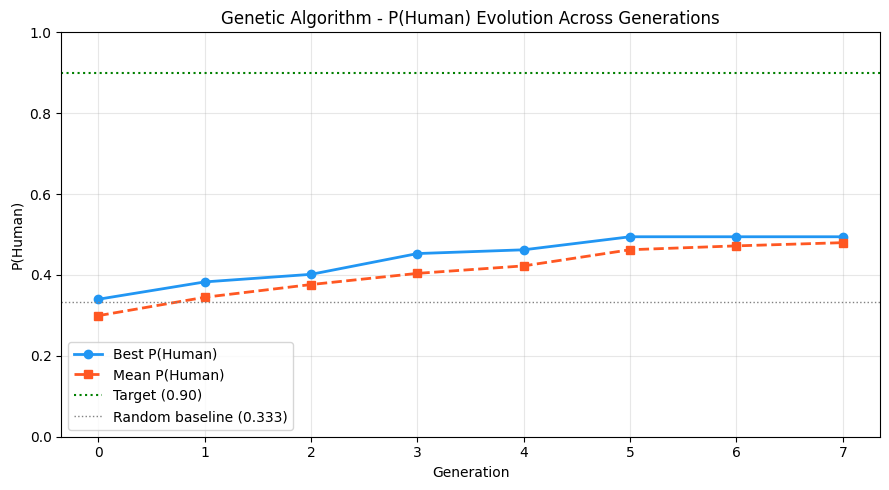

Figure saved.

--- BEST PARAGRAPH PER GENERATION ---

--- Generation 0 | P(Human)=0.3400 ---
Father Michael poured the wine, his movements slow and deliberate. He had heard countless confessions, each one a tapestry of human frailty and desperation. Yet, the young man before him, with his downcast eyes and trembling hands, carried a burden that seemed to weigh more heavily than others. He s...

--- Generation 1 | P(Human)=0.3828 ---
Father Michael, whose hands moved with a practiced, unhurried grace, poured the sacramental wine, a ritual he had performed countless times before. He had listened to innumerable confessions, each one a complex tapestry woven from threads of human frailty and profound desperation, though this partic...

--- Generation 2 | P(Human)=0.4016 ---
Father Michael, whose hands moved with a practiced, unhurried grace, poured the sacramental wine, a ritual he had performed countless times before. He had listened to innumerable confessions, each one a complex tapestry

In [ ]:
# Plotting fitness evolution 
generations_x = [h['generation'] for h in ga_history]
best_scores   = [h['best']       for h in ga_history]
mean_scores   = [h['mean']       for h in ga_history]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(generations_x, best_scores, marker='o', label='Best P(Human)',
        color='#2196F3', linewidth=2)
ax.plot(generations_x, mean_scores, marker='s', label='Mean P(Human)',
        color='#FF5722', linewidth=2, linestyle='--')
ax.axhline(y=0.90, color='green',  linestyle=':', linewidth=1.5, label='Target (0.90)')
ax.axhline(y=0.333, color='gray', linestyle=':', linewidth=1,   label='Random baseline (0.333)')
ax.set_xlabel('Generation')
ax.set_ylabel('P(Human)')
ax.set_title('Genetic Algorithm - P(Human) Evolution Across Generations')
ax.legend()
ax.set_ylim(0, 1)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'ga_fitness_curve.png'), dpi=150)
plt.show()
print('Figure saved.')

# Best paragraph per generation
print('\n--- BEST PARAGRAPH PER GENERATION ---\n')
for h in ga_history:
    snippet = h['best_text'][:300] + '...' if len(h['best_text']) > 300 else h['best_text']
    print(f'--- Generation {h["generation"]} | P(Human)={h["best"]:.4f} ---')
    print(snippet)
    print()

# Final winner
winner = final_population[0]
p_human_final, pred_final, probs_final = get_human_probability(winner['text'])
print('--- FINAL WINNER ---')
print(f'P(Human)={probs_final[0]:.4f} | P(GenAI)={probs_final[1]:.4f} | P(MimicAI)={probs_final[2]:.4f}')
print(f'Predicted: {label_names[pred_final]}')
print(f'\nText:\n{winner["text"]}')

# Saving results
results = {
    'history':     ga_history,
    'winner':      winner,
    'final_probs': probs_final.tolist()
}
with open('../data/task4/ga_results.json', 'w') as f:
    json.dump(results, f, indent=2)
print('\nResults saved to ../data/task4/ga_results.json')

### **Genetic Algorithm Results**

The Genetic Algorithm (GA) ran for 7 generations with population size 10 and 3 survivors per generation. It started from a best P(Human) of 0.34, reached 0.4945 by generation 5 and then completely flattened. I can see that generations 5, 6, and 7 have the same best paragraph. This means that the algorithm found a local optimum and had no path forward.

1. My first hypothesis (H1) is confirmed. Task 3's  adversarial tests predicted that single-feature mutations cannot push a paragraph across the decision boundary because the model requires a combination of past tense, Victorian vocabulary, and syntactic complexity. Hence the plateau at around *0.49*.

2. The GA converged at generation 5 and stayed there. It is probably because Gemini's small vocabulary changes did not change the overall structure. The fitness curve also confirms this. Both best and mean P(Human) rose from generations 0 to 5, then the gap between them decreased and both flatlined.

3. The best paragraph after 7 generations was predicted as Human with P(Human)=0.4945, which is barely above the random baseline of 0.333. It was classified as Human but the model's confidence was almost uniform across the classes. This means that GA got close to the decision boundary but Gemini's definition of "Victorian style" is different from Mary Shelley's Victorian style.


---

### **Part 2: Personal Test**

This part is about finding out if the detector will flag my own writing. I have written a short essay and will run it on the Tier C model (DistilBERT+LoRA). I will also rewrite the same essay in an explicit AI style to see how the model will react to it.

My essay covers: first-person narrative,  mixed-tense, conversational, no Victorian vocabulary.

**Expected finding (H2):** I think the model will classify this as Generic AI or borderline, because its training for the Human class contained only Victorian texts by Shelley and Dickens.

--- ESSAY ---
Predicted: Generic AI
P(Human)=0.3311 | P(GenAI)=0.3867 | P(MimicAI)=0.2823

--- AI-STYLE REWRITE OF SAME CONTENT ---
Predicted: Generic AI
P(Human)=0.2548 | P(GenAI)=0.4822 | P(MimicAI)=0.2630


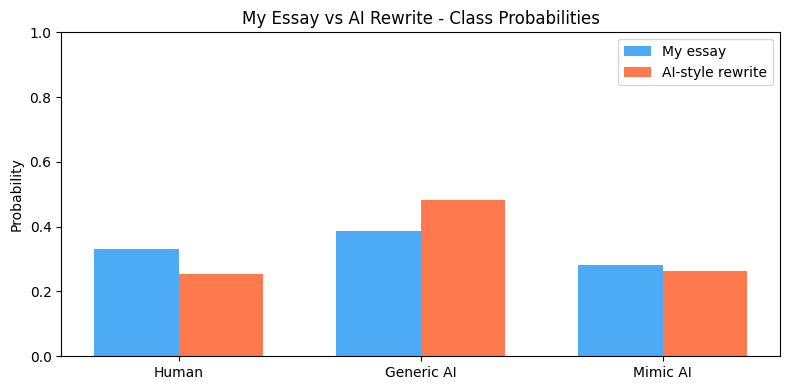

Figure saved.


In [ ]:
essay = (
    "When I first read a research paper, I understood nothing. I\n"
    "was sitting in my room with a Transformer paper on my screen,\n"
    "highlighting words I didn't know. I gave up after three pages\n"
    "and watched YouTube instead. That was two years ago.\n\n"
    "What changed wasn't that the papers got easier. What changed\n"
    "was that I stopped expecting to understand everything in the\n"
    "first read. My professor told me once that a paper is a conversation,\n"
    "not a lecture. We're supposed to argue back, ask questions, and get\n"
    "annoyed. I started doing that, making notes, looking things up out\n"
    "of annoyance more than curiosity.\n\n"
    "I'm not sure if I've become a researcher yet. But I know I'm not the\n"
    "person who gave up after three pages. That feels enough for now."
)

p_human_essay, pred_essay, probs_essay = get_human_probability(essay)
print('--- ESSAY ---')
print(f'Predicted: {label_names[pred_essay]}')
print(f'P(Human)={probs_essay[0]:.4f} | P(GenAI)={probs_essay[1]:.4f} | P(MimicAI)={probs_essay[2]:.4f}')

# AI-style rewrite of the same first paragraph (same content)
ai_rewrite = (
    "The initial exposure to academic literature presented significant\n"
    "challenges in terms of comprehension and information processing. The\n"
    "dense technical terminology and complex methodological frameworks\n"
    "inherent in transformer architecture research created substantial\n"
    "barriers to effective knowledge acquisition. Despite sustained\n"
    "engagement with the material, meaningful understanding remained\n"
    "elusive, necessitating alternative approaches to content consumption."
)

p_human_ai, pred_ai, probs_ai = get_human_probability(ai_rewrite)
print('\n--- AI-STYLE REWRITE OF SAME CONTENT ---')
print(f'Predicted: {label_names[pred_ai]}')
print(f'P(Human)={probs_ai[0]:.4f} | P(GenAI)={probs_ai[1]:.4f} | P(MimicAI)={probs_ai[2]:.4f}')

# Comparison bar chart
fig, ax = plt.subplots(figsize=(8, 4))
classes = ['Human', 'Generic AI', 'Mimic AI']
x       = np.arange(len(classes))
width   = 0.35
ax.bar(x - width/2, probs_essay, width, label='My essay',    color='#2196F3', alpha=0.8)
ax.bar(x + width/2, probs_ai,    width, label='AI-style rewrite', color='#FF5722', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.set_ylabel('Probability')
ax.set_title('My Essay vs AI Rewrite - Class Probabilities')
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'essay_comparison.png'), dpi=150)
plt.show()
print('Figure saved.')


### **Personal Test Results**

My second hypothesis (H2) is confirmed. My essay was classified as Generic AI (P(GenAI)=0.387, P(Human)=0.331). My AI-style rewrite was also classified as Generic AI but with higher confidence (P(GenAI)=0.482).

The bar chart also shows that the AI rewrite has a much taller orange bar for Generic AI and a much shorter bar for Human compared to the genuine essay. This means that the model detected that my rewrite was more AI-like and moved in the right direction. But it couldn't recognize my original essay as Human.

It is not surprising because my essay is written in conversational modern English, first person, with mixed tense (past for events, present for reflection). It has no Victorian vocabulary, no semicolons, no em-dashes, no Gothic prose, hence, it has none of the features that the model associates with Human class.

**Humanizing my essay:** The task asked if I can manually lower my "AI score" if the model flags my writing as AI. I can, but only by writing like Shelley, i.e., adding semicolons, switching to pure past tense, and using complex vocabulary. But this is not "humanizing". This is "Victorianizing". 

I believe this is the finding of the whole assignment.

### **Conclusion of "The Ghost in the Machine"**

The assignment asked me two questions: Can I evolve a paragraph that bypasses my detector and can I fool my machine with my own writing.

The answer to the first question is, "almost". Seven generations of evolution pushed a Generic AI paragraph to P(Human)=0.4945, which was classified as Human. The convergence of the GA at around 0.49 means that the algorithm hit a wall and can't climb it. I can't bypass my own detector with simple mutations.

The answer to the second question is, "no". This is not because I write like AI, it is because the model did not learn how humans actually write. It only learned one specific style of human writing. My essay would look "human" to a human reader, but the model sees it as "Generic AI".

I have spent thirteen days trying to find the ghost in Victorian texts. My model found it, i.e., it can differentiate between Mary Shelley and Gemini with 100% accuracy. 

But it can't recognize a human who does not write like Shelley. 

---

### **AI and Tool usage**

I designed the three mutation prompts (tense register, vocabulary replacement, syntactic complexity) based on the findings of Task 3, and [Github Copilot](https://github.com/copilot) in my IDE generated the Genetic Algorithm code structure after I described my approach. It then also helped me write the mutation functions and the visualization code for the fitness trajectory. 